# Notebook 02 — Retrieval Strategy Comparison

**RAGScope · MSc Data Science Dissertation · Leeds Beckett University · 2026**

---

## Purpose

This notebook compares the two retrieval strategies implemented in RAGScope:

| Strategy | Description | Conditions |
|---|---|---|
| **Dense** | ChromaDB cosine ANN search over `all-MiniLM-L6-v2` embeddings | A (Llama3), C (Mistral) |
| **Hybrid** | BM25 + Dense fused via Reciprocal Rank Fusion (RRF, k=60) | B (Llama3), D (Mistral) |

### Research Questions Addressed

- **RQ1** — Which retrieval strategy produces higher context relevance scores?
- **RQ3** — What performance trade-offs exist between dense and hybrid retrieval across latency, faithfulness, and cost?

### Notebook Structure

1. Load and inspect telemetry records from both retrieval conditions
2. Compare retrieval score distributions (top chunk score, mean chunk score)
3. Compare RAGAS context relevance and answer faithfulness across conditions
4. Compare latency decomposition: embed_query_ms, search_ms, rrf_fusion_ms
5. Analyse the token count and cost implications of each strategy
6. Pairwise Cohen's d effect sizes: dense vs. hybrid
7. Correlation analysis: retrieval latency vs. quality metrics

### Prerequisites

The benchmark experiment must have been run before executing this notebook:
```bash
uv run python experiments/run_2x2_factorial.py --dataset all --conditions all
```
This notebook loads from `experiments/results/*.csv`.

## 0. Setup and Data Loading

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as scipy_stats

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.metrics import descriptive_stats, cohens_d, pearson_r
from evaluation.hallucination_score import risk_band
from config.settings import settings

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PURPLE = "#522D80"
TEAL   = "#17a2b8"
AMBER  = "#f39c12"
RED    = "#e74c3c"
DENSE_COLOR  = PURPLE
HYBRID_COLOR = TEAL

RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
FIGURES_DIR = PROJECT_ROOT / "experiments" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Looking for results in: {RESULTS_DIR.resolve()}")

Looking for results in: /app/experiments/results


In [ ]:
# ── Load the benchmark results CSV ────────────────────────────────────────────
csv_files = sorted(RESULTS_DIR.glob("benchmark_*.csv"), reverse=True)

if not csv_files:
    print("No benchmark CSVs found.")
    print("Run: uv run python experiments/run_2x2_factorial.py --dataset all --conditions all")
    raise SystemExit("Failed to load benchmark CSV")

latest_csv = csv_files[0]
print(f"Loading: {latest_csv.name}")
df = pd.read_csv(latest_csv)

print(f"Total records : {len(df):,}")
print(f"Columns       : {list(df.columns)}")

print(f"\nCondition counts:")
print(df.groupby(["llm_model", "retrieval_strategy"]).size().reset_index(name="n").to_string(index=False))

# Surfaced explicitly because it changes how every result below should be
# read: a full dissertation-scale run covers all three source datasets, but
# this notebook always loads whichever CSV is newest, which may be a
# partial/single-dataset test run instead (see the note above).
if "dataset" in df.columns:
    print(f"\nDataset composition:")
    print(df["dataset"].value_counts().to_string())

> **Data provenance:** this loads whichever `benchmark_*.csv` sorts last by filename (most recent timestamp), not necessarily the full dissertation-scale run. Check the "Dataset composition" printed above — if it shows only one dataset rather than all three (`msmarco`, `natural_questions`, `hotpotqa`), you're looking at a partial or single-dataset test run, not the full 200-query × 4-condition (800-record) experiment. Treat every Cohen's d and correlation result below as **provisional** until re-run against the full `--dataset all` experiment (see the README's "Running the Benchmark Evaluation"). In particular, small sample sizes push effect sizes toward "negligible" almost by default — don't read a negligible *d* here as a settled finding.

In [11]:
# ── Convenience subsets ───────────────────────────────────────────────────────
dense  = df[df["retrieval_strategy"] == "dense"].copy()
hybrid = df[df["retrieval_strategy"] == "hybrid"].copy()

llama3_dense   = df[(df.llm_model=="llama3")  & (df.retrieval_strategy=="dense")]
llama3_hybrid  = df[(df.llm_model=="llama3")  & (df.retrieval_strategy=="hybrid")]
mistral_dense  = df[(df.llm_model=="mistral") & (df.retrieval_strategy=="dense")]
mistral_hybrid = df[(df.llm_model=="mistral") & (df.retrieval_strategy=="hybrid")]

print(f"Dense records  : {len(dense)}")
print(f"Hybrid records : {len(hybrid)}")

Dense records  : 80
Hybrid records : 80


## 1. Retrieval Score Distributions

KeyError: 'mean_chunk_score'

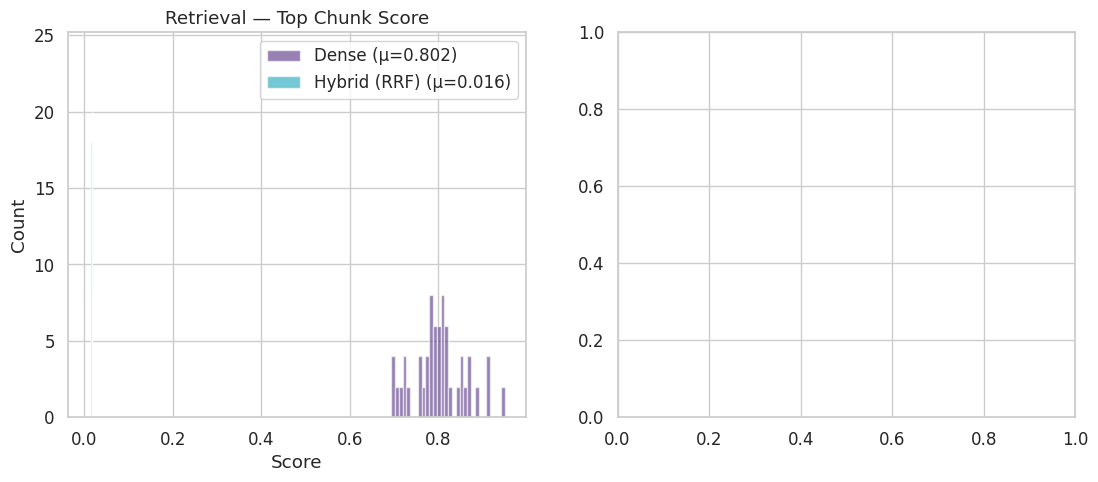

In [12]:
# ── Top chunk similarity score: dense vs. hybrid ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "top_chunk_score",  "Top Chunk Score"),
    (axes[1], "mean_chunk_score", "Mean Chunk Score (top-k)"),
]:
    for strategy, color, label in [
        ("dense",  DENSE_COLOR,  "Dense"),
        ("hybrid", HYBRID_COLOR, "Hybrid (RRF)"),
    ]:
        vals = df[df.retrieval_strategy == strategy][col].dropna()
        ax.hist(vals, bins=30, alpha=0.6, color=color,
                edgecolor="white", label=f"{label} (μ={vals.mean():.3f})")
    ax.set_title(f"Retrieval — {title}")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Retrieval Score Distributions: Dense vs. Hybrid",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_retrieval_scores.png", dpi=150, bbox_inches="tight")
plt.show()

for col in ["top_chunk_score", "mean_chunk_score"]:
    d_vals = dense[col].dropna().tolist()
    h_vals = hybrid[col].dropna().tolist()
    cd     = cohens_d(d_vals, h_vals, "Dense", "Hybrid", col)
    print(f"{col}: dense μ={cd.mean_a:.4f}, hybrid μ={cd.mean_b:.4f}, "
          f"d={cd.d:+.4f} ({cd.magnitude})")

**Note:** RRF scores are not directly comparable to cosine similarity scores — they represent rank-weighted fusion scores rather than vector distances. The distributions will look qualitatively different. What matters for the experiment is the downstream effect on RAGAS metrics.

## 2. RAGAS Quality Metrics: Dense vs. Hybrid

/tmp/ipykernel_148/2642434591.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_148/2642434591.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_148/2642434591.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_148/2642434591.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


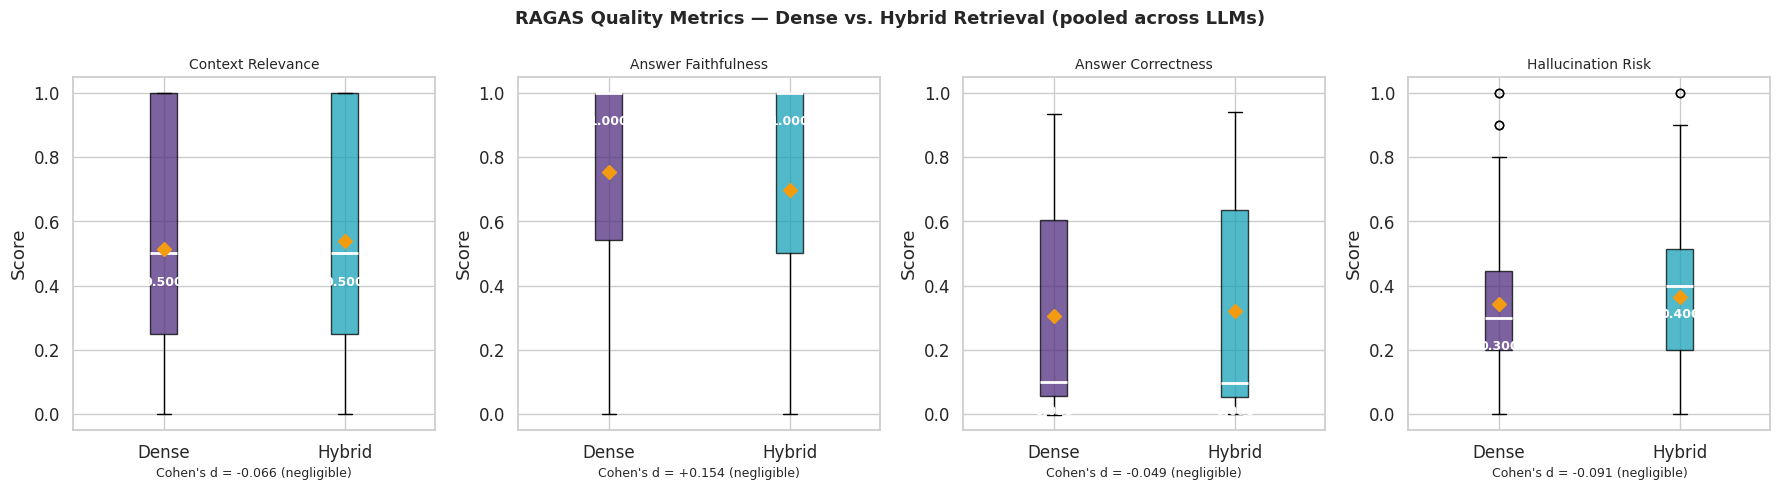

In [13]:
# ── Box plots: context_relevance and answer_faithfulness ──────────────────────
QUALITY_METRICS = ["context_relevance", "answer_faithfulness",
                   "answer_correctness", "hallucination_risk"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, QUALITY_METRICS):
    data_dense  = dense[metric].dropna()
    data_hybrid = hybrid[metric].dropna()

    bp = ax.boxplot(
        [data_dense, data_hybrid],
        patch_artist=True,
        labels=["Dense", "Hybrid"],
        medianprops={"color": "white", "linewidth": 2},
        showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": AMBER,
                   "markeredgecolor": AMBER, "markersize": 7},
    )
    for patch, color in zip(bp["boxes"], [DENSE_COLOR, HYBRID_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(metric.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Score")
    ax.set_ylim(-0.05, 1.05)

    # Annotate medians
    for i, data in enumerate([data_dense, data_hybrid], 1):
        ax.text(i, data.median() - 0.07, f"{data.median():.3f}",
                ha="center", va="top", fontsize=9, color="white", fontweight="bold")

    # Cohen's d annotation
    cd = cohens_d(data_dense.tolist(), data_hybrid.tolist(),
                  "Dense", "Hybrid", metric)
    ax.set_xlabel(f"Cohen's d = {cd.d:+.3f} ({cd.magnitude})", fontsize=9)

plt.suptitle("RAGAS Quality Metrics — Dense vs. Hybrid Retrieval (pooled across LLMs)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_ragas_dense_vs_hybrid.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# ── Descriptive statistics table: dense vs. hybrid ────────────────────────────
rows = []
for metric in QUALITY_METRICS:
    s_dense  = descriptive_stats(dense[metric].dropna().tolist(),  metric)
    s_hybrid = descriptive_stats(hybrid[metric].dropna().tolist(), metric)
    cd = cohens_d(dense[metric].dropna().tolist(),
                  hybrid[metric].dropna().tolist(), "Dense", "Hybrid", metric)
    rows.append({
        "Metric":           metric.replace("_"," ").title(),
        "Dense μ (σ)":      f"{s_dense.mean:.3f}  ({s_dense.std:.3f})",
        "Hybrid μ (σ)":     f"{s_hybrid.mean:.3f}  ({s_hybrid.std:.3f})",
        "Δ (Hybrid−Dense)": f"{s_hybrid.mean - s_dense.mean:+.3f}",
        "Cohen's d":        f"{cd.d:+.4f}",
        "Magnitude":        cd.magnitude,
    })

stats_df = pd.DataFrame(rows)
print("=== Dense vs. Hybrid — Summary Statistics ===")
print(stats_df.to_string(index=False))

=== Dense vs. Hybrid — Summary Statistics ===
             Metric    Dense μ (σ)   Hybrid μ (σ) Δ (Hybrid−Dense) Cohen's d  Magnitude
  Context Relevance 0.513  (0.360) 0.537  (0.388)           +0.025   -0.0664 negligible
Answer Faithfulness 0.754  (0.350) 0.698  (0.369)           -0.055   +0.1538 negligible
 Answer Correctness 0.305  (0.341) 0.322  (0.353)           +0.017   -0.0489 negligible
 Hallucination Risk 0.343  (0.256) 0.366  (0.257)           +0.023   -0.0907 negligible


## 3. Latency Decomposition

In [ ]:
# ── Latency breakdown: dense vs. hybrid by stage ──────────────────────────────
# Dense retrieval_ms  = embed_query_ms + vector_search_ms
# Hybrid retrieval_ms = embed_query_ms + dense_search_ms + bm25_search_ms + rrf_fusion_ms
# e2e_ms = retrieval_ms + generation_ms + evaluation_ms (+ a small amount of
# token-counting/telemetry-write overhead). evaluation_ms (the RAGAS judge
# LLM call(s)) routinely dominates e2e_ms — easy to miss if you only look at
# retrieval_ms/generation_ms, since neither one includes it.
latency_cols = ["retrieval_ms", "generation_ms", "e2e_ms"]
if "evaluation_ms" in df.columns:
    latency_cols.insert(2, "evaluation_ms")  # keep e2e_ms last, as the total

fig, axes = plt.subplots(1, len(latency_cols), figsize=(5 * len(latency_cols), 5))

for ax, col in zip(axes, latency_cols):
    for strategy, color, label in [
        ("dense",  DENSE_COLOR,  "Dense"),
        ("hybrid", HYBRID_COLOR, "Hybrid"),
    ]:
        vals = df[df.retrieval_strategy == strategy][col].dropna()
        ax.hist(vals, bins=35, alpha=0.60, color=color, edgecolor="white",
                label=f"{label} (μ={vals.mean():.0f} ms)")
    ax.set_title(f"{col.replace('_ms','').replace('_',' ').title()} Latency")
    ax.set_xlabel("Milliseconds")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Latency Distributions — Dense vs. Hybrid",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_latency_dense_vs_hybrid.png", dpi=150, bbox_inches="tight")
plt.show()

print("Latency comparison (ms):")
for col in latency_cols:
    d_mean = dense[col].mean()
    h_mean = hybrid[col].mean()
    overhead = h_mean - d_mean
    print(f"  {col:<16} dense={d_mean:>7.0f}  hybrid={h_mean:>7.0f}  "
          f"overhead={overhead:>+7.0f} ms ({overhead/d_mean*100:+.1f}%)")

if "evaluation_ms" not in df.columns:
    print("\nNote: this CSV predates the evaluation_ms column — e2e_ms still")
    print("includes evaluation time, it just isn't broken out separately here.")

In [ ]:
# ── Stacked latency bars: retrieval vs. generation (vs. evaluation) breakdown ─
conditions = ["Llama3+Dense", "Llama3+Hybrid", "Mistral+Dense", "Mistral+Hybrid"]
cond_data  = [llama3_dense, llama3_hybrid, mistral_dense, mistral_hybrid]
has_eval = "evaluation_ms" in df.columns

retrieval_means  = [d["retrieval_ms"].mean()  for d in cond_data]
generation_means = [d["generation_ms"].mean() for d in cond_data]
evaluation_means = [d["evaluation_ms"].mean() for d in cond_data] if has_eval else [0] * len(cond_data)
e2e_means        = [d["e2e_ms"].mean() for d in cond_data]  # true total, from its own timer

x = np.arange(len(conditions))
fig, ax = plt.subplots(figsize=(10, 5))

retrieval_colors  = [PURPLE, TEAL, PURPLE, TEAL]
generation_colors = ["#8e44ad", "#1a8fa0", "#8e44ad", "#1a8fa0"]
evaluation_colors = ["#e74c3c", "#e67e22", "#e74c3c", "#e67e22"]

ax.bar(x, retrieval_means, color=retrieval_colors, alpha=0.85,
       label="Retrieval", edgecolor="white")
ax.bar(x, generation_means, bottom=retrieval_means, color=generation_colors,
       alpha=0.85, label="Generation", edgecolor="white")
if has_eval:
    stack_base = [r + g for r, g in zip(retrieval_means, generation_means)]
    ax.bar(x, evaluation_means, bottom=stack_base, color=evaluation_colors,
           alpha=0.85, label="Evaluation (RAGAS)", edgecolor="white")

# Label each bar with the TRUE mean e2e_ms (its own timer), not the sum of the
# stacked segments — if evaluation_ms isn't in this CSV, the visible stack
# understates the real total, and this keeps the printed label honest about it.
for i, total in enumerate(e2e_means):
    ax.text(i, total + max(e2e_means) * 0.01, f"{total:,.0f} ms", ha="center",
            va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=10)
ax.set_ylabel("Milliseconds")
title = "Mean E2E Latency Decomposition by Condition"
if not has_eval:
    title += "\n(this CSV predates evaluation_ms — it's included in each label's\ntotal but not shown as its own stacked segment)"
ax.set_title(title, fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_latency_stacked.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Dataset-Level Retrieval Analysis

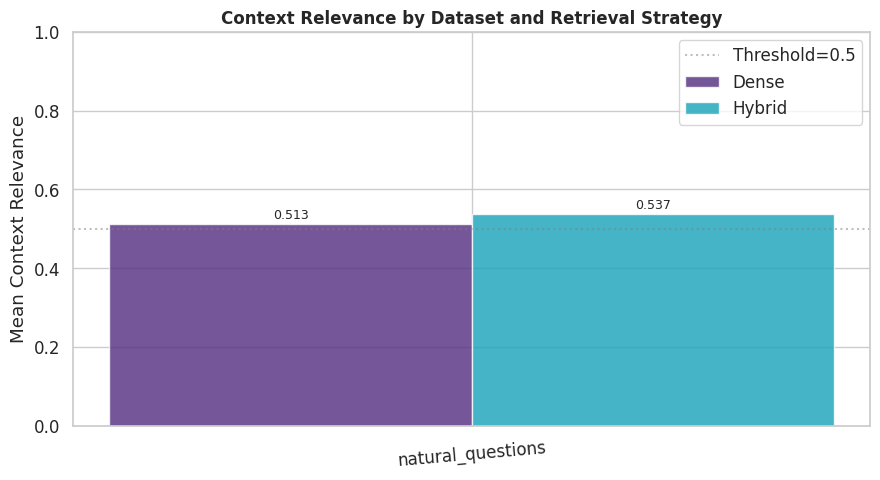

Mean Context Relevance by Dataset × Strategy:
retrieval_strategy   dense  hybrid
dataset                           
natural_questions   0.5127  0.5375


In [17]:
# ── Context relevance by dataset × retrieval strategy ─────────────────────────
if "dataset" in df.columns and "context_relevance" in df.columns:
    pivot = df.groupby(["dataset", "retrieval_strategy"])["context_relevance"].mean().unstack()

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(pivot.index))
    w = 0.35

    for i, (strategy, color) in enumerate([("dense", DENSE_COLOR), ("hybrid", HYBRID_COLOR)]):
        if strategy in pivot.columns:
            bars = ax.bar(x + i*w - w/2, pivot[strategy], w,
                          color=color, alpha=0.8, label=strategy.title(),
                          edgecolor="white")
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.005,
                        f"{bar.get_height():.3f}",
                        ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=5)
    ax.set_ylabel("Mean Context Relevance")
    ax.set_ylim(0, 1.0)
    ax.set_title("Context Relevance by Dataset and Retrieval Strategy",
                 fontsize=12, fontweight="bold")
    ax.axhline(0.5, color="grey", linestyle=":", alpha=0.5, label="Threshold=0.5")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig_context_rel_by_dataset.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Mean Context Relevance by Dataset × Strategy:")
    print(pivot.round(4).to_string())

## 5. Token Usage and Cost Analysis

Token Usage by Retrieval Strategy:
                   prompt_tokens                                                   completion_tokens                                            total_tokens                                                  
                           count   mean    std    min    25%    50%    75%     max             count  mean   std   min   25%   50%   75%    max        count   mean    std    min    25%    50%    75%     max
retrieval_strategy                                                                                                                                                                                            
dense                       80.0  783.0  264.5  403.0  637.2  724.0  831.5  2035.0              80.0  56.8  40.7   7.0  27.8  46.0  68.8  233.0         80.0  839.8  263.5  445.0  698.5  777.5  878.5  2058.0
hybrid                      80.0  787.3  266.8  458.0  628.8  712.5  860.2  1952.0              80.0  53.6  31.0  18.0  28.8  47.0  67.0 

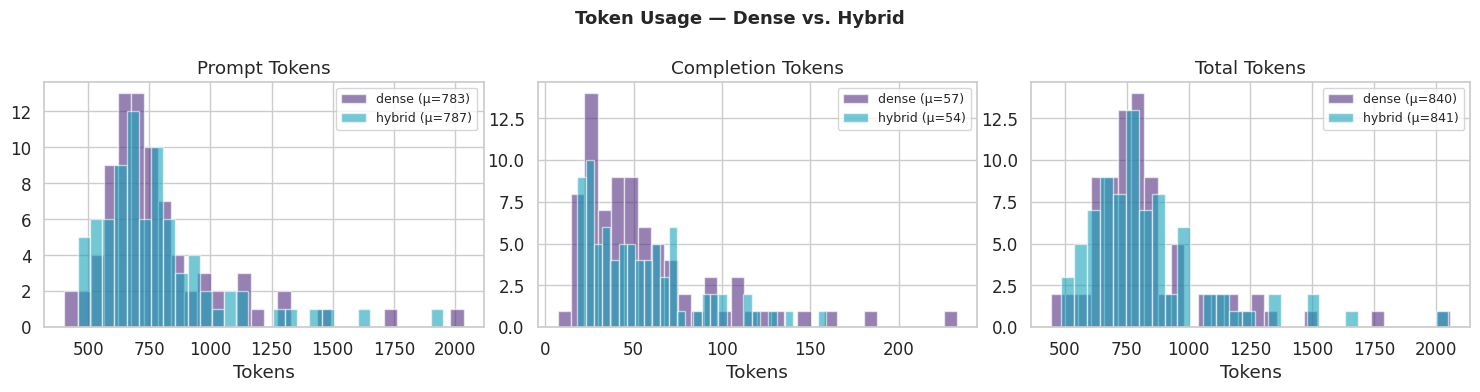

In [18]:
# ── Prompt token counts: dense vs. hybrid ─────────────────────────────────────
# Hybrid retrieval fetches more candidates (50 dense + 50 BM25), then re-ranks.
# The number of chunks injected into the prompt is controlled by top_k (same for both).
# So prompt token counts should be similar. This cell verifies that assumption.

token_cols = ["prompt_tokens", "completion_tokens", "total_tokens"]

token_summary = df.groupby("retrieval_strategy")[token_cols].describe().round(1)
print("Token Usage by Retrieval Strategy:")
print(token_summary.to_string())

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, token_cols):
    for strategy, color in [("dense", DENSE_COLOR), ("hybrid", HYBRID_COLOR)]:
        vals = df[df.retrieval_strategy == strategy][col].dropna()
        ax.hist(vals, bins=30, alpha=0.60, color=color,
                edgecolor="white", label=f"{strategy} (μ={vals.mean():.0f})")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Tokens")
    ax.legend(fontsize=9)

plt.suptitle("Token Usage — Dense vs. Hybrid", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_tokens_dense_vs_hybrid.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Hallucination Risk: Dense vs. Hybrid

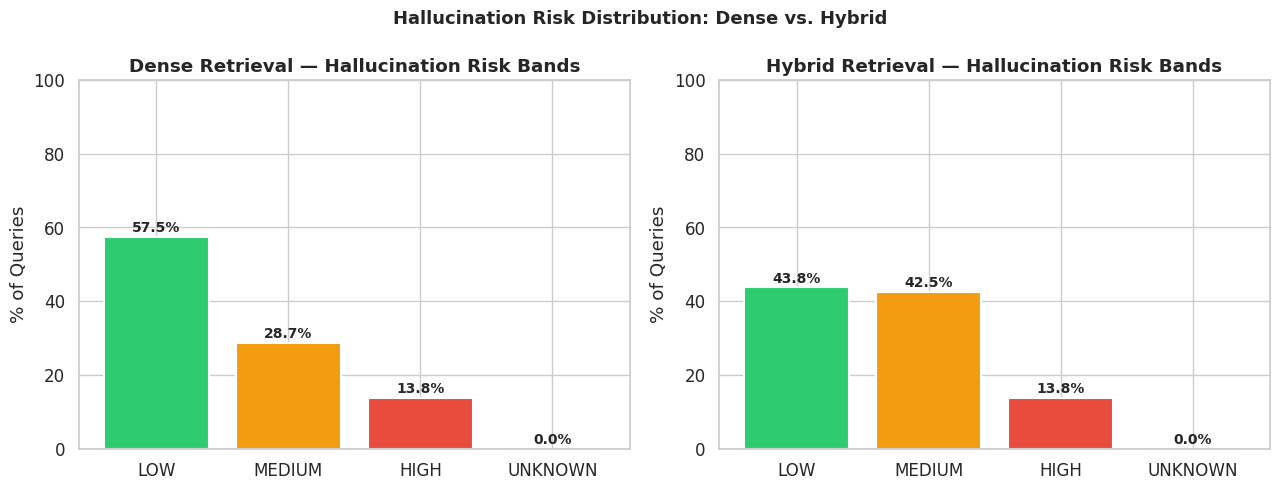


Risk band comparison:
risk_band           HIGH  LOW  MEDIUM
retrieval_strategy                   
dense                 11   46      23
hybrid                11   35      34


In [19]:
# ── Hallucination risk band distribution: dense vs. hybrid ────────────────────
df["risk_band"] = df["hallucination_risk"].apply(risk_band)

BAND_COLORS = {"LOW": "#2ecc71", "MEDIUM": "#f39c12", "HIGH": "#e74c3c", "UNKNOWN": "#95a5a6"}
BAND_ORDER  = ["LOW", "MEDIUM", "HIGH", "UNKNOWN"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, strategy in zip(axes, ["dense", "hybrid"]):
    subset = df[df.retrieval_strategy == strategy]
    counts = subset["risk_band"].value_counts().reindex(BAND_ORDER, fill_value=0)
    pcts   = counts / len(subset) * 100

    bars = ax.bar(counts.index, pcts,
                  color=[BAND_COLORS[b] for b in counts.index],
                  edgecolor="white", linewidth=1.5)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=10)

    ax.set_title(f"{strategy.title()} Retrieval — Hallucination Risk Bands",
                 fontweight="bold")
    ax.set_ylabel("% of Queries")
    ax.set_ylim(0, 100)

plt.suptitle("Hallucination Risk Distribution: Dense vs. Hybrid",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_risk_bands.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRisk band comparison:")
print(df.groupby(["retrieval_strategy", "risk_band"]).size()
      .unstack(fill_value=0).to_string())

## 7. Pairwise Cohen's d Effect Sizes

In [ ]:
# ── Cohen's d: dense vs. hybrid, stratified by LLM ───────────────────────────
# evaluation_ms is only present in CSVs generated after RAGAS evaluation time
# was tracked as its own field — the `if metric not in d_data.columns` guard
# below skips it gracefully for older CSVs rather than raising a KeyError.
ALL_METRICS = QUALITY_METRICS + ["e2e_ms", "evaluation_ms", "total_tokens"]

rows = []
for llm, d_data, h_data in [
    ("llama3",  llama3_dense,  llama3_hybrid),
    ("mistral", mistral_dense, mistral_hybrid),
    ("pooled",  dense,         hybrid),
]:
    for metric in ALL_METRICS:
        if metric not in d_data.columns:
            continue
        d_vals = d_data[metric].dropna().tolist()
        h_vals = h_data[metric].dropna().tolist()
        cd = cohens_d(d_vals, h_vals, f"{llm}_dense", f"{llm}_hybrid", metric)
        rows.append({
            "LLM":        llm,
            "Metric":     metric.replace("_"," ").title(),
            "Dense μ":    round(cd.mean_a, 4),
            "Hybrid μ":   round(cd.mean_b, 4),
            "Δ":          round(cd.mean_b - cd.mean_a, 4),
            "Cohen's d":  cd.d,
            "Magnitude":  cd.magnitude,
        })

cd_df = pd.DataFrame(rows)
print("=== Dense vs. Hybrid — Cohen's d Effect Sizes ===")
print(cd_df.to_string(index=False))

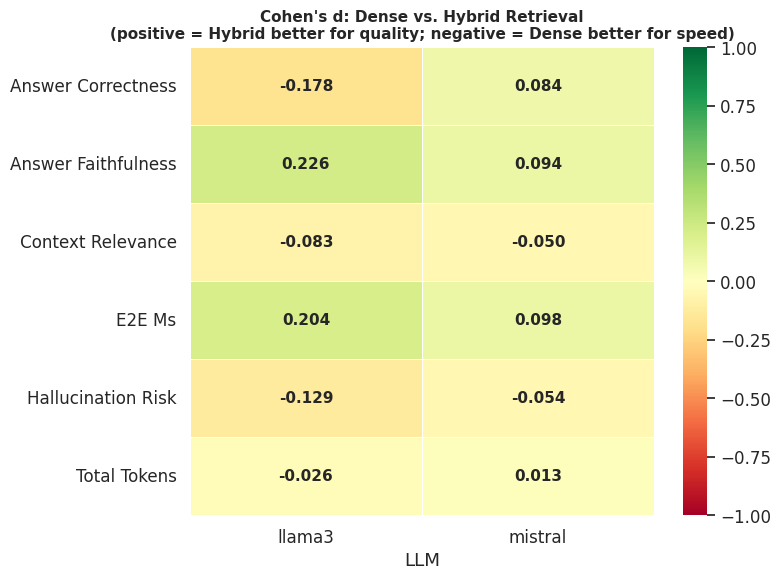

In [21]:
# ── Heatmap of Cohen's d ─────────────────────────────────────────────────────
pivot_cd = cd_df[cd_df.LLM != "pooled"].pivot(index="Metric", columns="LLM", values="Cohen's d")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_cd, annot=True, fmt=".3f", cmap="RdYlGn",
            center=0, vmin=-1.0, vmax=1.0,
            linewidths=0.5, ax=ax,
            annot_kws={"size": 11, "weight": "bold"})
ax.set_title("Cohen's d: Dense vs. Hybrid Retrieval\n(positive = Hybrid better for quality; negative = Dense better for speed)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("LLM")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_cohens_d_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Correlation: Retrieval Latency vs. Quality Metrics

In [22]:
# ── Pearson r: retrieval_ms vs. each quality metric ───────────────────────────
print("Pearson r — Retrieval Latency vs. Quality Metrics:\n")
print(f"{'Metric':<25} {'Pooled':>8} {'Dense':>8} {'Hybrid':>8}")
print("-" * 55)

for metric in QUALITY_METRICS:
    if metric not in df.columns:
        continue
    pooled_r = pearson_r(df["retrieval_ms"].tolist(), df[metric].tolist())
    dense_r  = pearson_r(dense["retrieval_ms"].tolist(), dense[metric].tolist())
    hybrid_r = pearson_r(hybrid["retrieval_ms"].tolist(), hybrid[metric].tolist())

    def fmt(r): return f"{r:+.4f}" if r is not None else "  N/A "
    print(f"{metric.replace('_',' ').title():<25} {fmt(pooled_r):>8} "
          f"{fmt(dense_r):>8} {fmt(hybrid_r):>8}")

Pearson r — Retrieval Latency vs. Quality Metrics:

Metric                      Pooled    Dense   Hybrid
-------------------------------------------------------
Context Relevance          +0.0105  -0.0361  +0.0156
Answer Faithfulness        -0.1543  -0.1659  -0.1123
Answer Correctness         -0.0215  -0.0656  -0.0337
Hallucination Risk         +0.1240  +0.1562  +0.0875


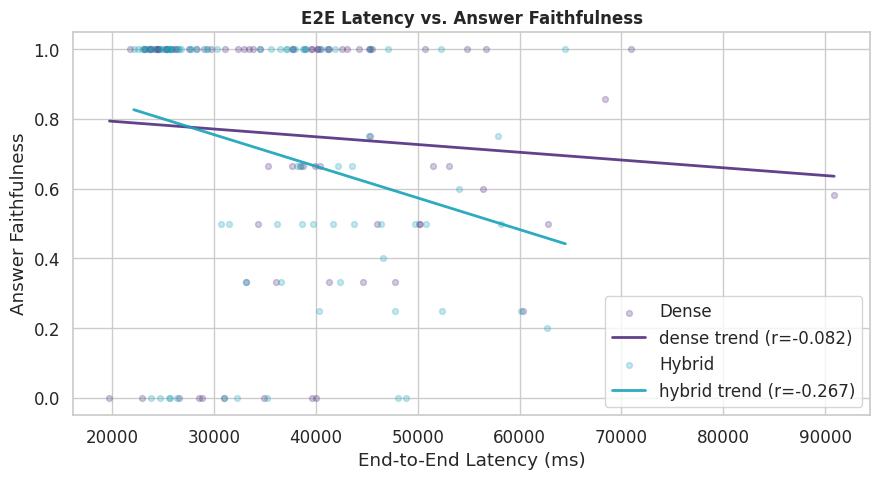

In [23]:
# ── Scatter: e2e_ms vs. answer_faithfulness coloured by strategy ──────────────
fig, ax = plt.subplots(figsize=(9, 5))

for strategy, color in [("dense", DENSE_COLOR), ("hybrid", HYBRID_COLOR)]:
    subset = df[(df.retrieval_strategy == strategy) &
                df["e2e_ms"].notna() &
                df["answer_faithfulness"].notna()]
    ax.scatter(subset["e2e_ms"], subset["answer_faithfulness"],
               alpha=0.25, color=color, s=18, label=strategy.title())

    # Regression line
    x_clean = subset["e2e_ms"].values
    y_clean = subset["answer_faithfulness"].values
    if len(x_clean) > 2:
        m, b, r, p, _ = scipy_stats.linregress(x_clean, y_clean)
        x_range = np.linspace(x_clean.min(), x_clean.max(), 100)
        ax.plot(x_range, m * x_range + b, color=color,
                linewidth=2, alpha=0.9, label=f"{strategy} trend (r={r:+.3f})")

ax.set_xlabel("End-to-End Latency (ms)")
ax.set_ylabel("Answer Faithfulness")
ax.set_title("E2E Latency vs. Answer Faithfulness", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_latency_vs_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Summary of Findings

In [24]:
# ── Auto-generate summary table ───────────────────────────────────────────────
print("=" * 70)
print("RETRIEVAL STRATEGY COMPARISON — KEY FINDINGS")
print("=" * 70)

for metric in QUALITY_METRICS:
    if metric not in df.columns:
        continue
    d_mean = dense[metric].mean()
    h_mean = hybrid[metric].mean()
    delta  = h_mean - d_mean
    cd     = cohens_d(dense[metric].dropna().tolist(),
                      hybrid[metric].dropna().tolist())
    winner = "Hybrid" if (
        (metric != "hallucination_risk" and delta > 0) or
        (metric == "hallucination_risk" and delta < 0)
    ) else "Dense"
    print(f"  {metric.replace('_',' ').title():<25} "
          f"Dense={d_mean:.4f}  Hybrid={h_mean:.4f}  "
          f"Δ={delta:+.4f}  d={cd.d:+.4f} ({cd.magnitude})  → {winner}")

print()
for col in ["retrieval_ms", "e2e_ms"]:
    d_mean = dense[col].mean()
    h_mean = hybrid[col].mean()
    overhead = h_mean - d_mean
    print(f"  {col.replace('_',' ').title():<25} "
          f"Dense={d_mean:.0f} ms  Hybrid={h_mean:.0f} ms  "
          f"overhead={overhead:+.0f} ms ({overhead/d_mean*100:+.1f}%)")

print("=" * 70)
print("Interpretation guide: Cohen's |d| < 0.2 negligible | 0.2–0.5 small | 0.5–0.8 medium | >0.8 large")

RETRIEVAL STRATEGY COMPARISON — KEY FINDINGS
  Context Relevance         Dense=0.5127  Hybrid=0.5375  Δ=+0.0248  d=-0.0664 (negligible)  → Hybrid
  Answer Faithfulness       Dense=0.7537  Hybrid=0.6983  Δ=-0.0553  d=+0.1538 (negligible)  → Dense
  Answer Correctness        Dense=0.3048  Hybrid=0.3218  Δ=+0.0170  d=-0.0489 (negligible)  → Hybrid
  Hallucination Risk        Dense=0.3427  Hybrid=0.3660  Δ=+0.0233  d=-0.0907 (negligible)  → Dense

  Retrieval Ms              Dense=98 ms  Hybrid=219 ms  overhead=+121 ms (+124.4%)
  E2E Ms                    Dense=38011 ms  Hybrid=36261 ms  overhead=-1750 ms (-4.6%)
Interpretation guide: Cohen's |d| < 0.2 negligible | 0.2–0.5 small | 0.5–0.8 medium | >0.8 large


---

*Next notebook: `03_hallucination_analysis.ipynb` — deep dive into hallucination patterns, risk score validation, and per-query failure mode inspection.*